# 📌 Financial Inclusion in Africa: Starter Notebook

This beginner-friendly guide walks you through a simple machine learning pipeline for predicting financial inclusion.


This is a simple starter notebook to get started with the Financial Inclusion Competition on Zindi.

This notebook covers:
- Loading the data
- Simple EDA and an example of feature enginnering
- Data preprocessing and data wrangling
- Creating a simple model
- Making a submission
- Some tips for improving your score

## Step 1: Import Libraries 🛠️

In [3]:
# 📌 Import necessary libraries for data handling, visualization, and modeling
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# # To download files
# from google.colab import files

# Suppress warnings for better readability
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the Dataset 📥

In [4]:
# 📥 Load datasets
train = pd.read_csv('Train.csv')  # Training dataset
test = pd.read_csv('Test.csv')  # Test dataset (no labels)
ss = pd.read_csv('SampleSubmission.csv')  # Sample submission format
variables = pd.read_csv('VariableDefinitions.csv')  # Data dictionary

# Display first few rows to understand structure
print("🔹 Training Data Preview:")
display(train.head())

print("🔹 Variable Definitions Preview:")
display(variables.head())

🔹 Training Data Preview:


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


🔹 Variable Definitions Preview:


,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"


In [5]:
# 📊 Check dataset shapes
print(f"✅ Train dataset: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"✅ Test dataset: {test.shape[0]} rows, {test.shape[1]} columns")

✅ Train dataset: 23524 rows, 13 columns
✅ Test dataset: 10086 rows, 12 columns


In [26]:
train

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,1,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,0,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,1,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,0,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,0,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23519,Uganda,2018,uniqueid_2113,0,Rural,Yes,4,48,Female,Head of Household,Divorced/Seperated,No formal education,Other Income
23520,Uganda,2018,uniqueid_2114,0,Rural,Yes,2,27,Female,Head of Household,Single/Never Married,Secondary education,Other Income
23521,Uganda,2018,uniqueid_2115,0,Rural,Yes,5,27,Female,Parent,Widowed,Primary education,Other Income
23522,Uganda,2018,uniqueid_2116,0,Urban,Yes,7,30,Female,Parent,Divorced/Seperated,Secondary education,Self employed


In [25]:
variables

,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...


The above output shows the number of rows and columns for train and test dataset. We have 13 variables in the train dataset, 12 independent variables and 1 dependent variable. In the test dataset, we have 12 independent variables.


In [11]:
# Check for missing values
print('missing values:', train.isnull().sum())

missing values: country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


We don't have missing data in our dataset.



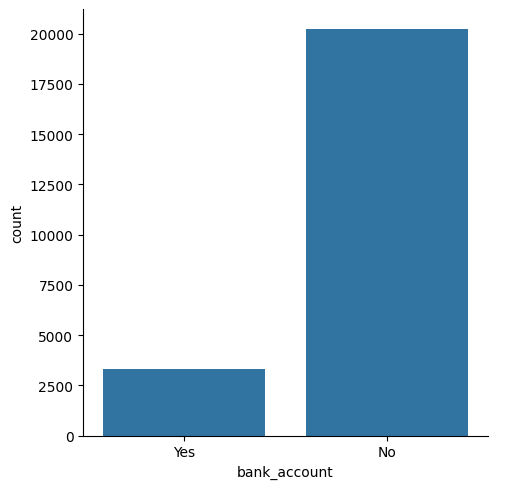

In [6]:
# Explore Target distribution
sns.catplot(x="bank_account", kind="count", data=train)

It is important to understand the meaning of each feature so you can really understand the dataset. You can read the VariableDefinition.csv file to understand the meaning of each variable presented in the dataset.

The SampleSubmission.csv gives us an example of how our submission file should look. This file will contain the uniqueid column combined with the country name from the Test.csv file and the target we predict with our model. Once we have created this file, we will submit it to the competition page and obtain a position on the leaderboard.


In [13]:
# view the submission file
ss.head()

,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


### 2. Understand the dataset
We can get more information about the features presented by using the info() method from pandas.


In [7]:
 #show some information about the dataset
 print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB
None


The output shows the list of variables/features, sizes, if it contains missing values and data type for each variable. From the dataset, we don’t have any missing values and we have 3 features of integer data type and 10 features of the object data type.

If you want to learn how to handle missing data in your dataset, we recommend you read How to [Handle Missing Data with Python](https://machinelearningmastery.com/handle-missing-data-python/) by Jason Brownlee.

We won’t go further on understanding the dataset because Davis has already published an article about exploratory data analysis (EDA) with the financial Inclusion in Africa dataset. You can read and download the notebook for EDA in the link below.

[Why you need to explore your data and how you can start](https://https://medium.com/analytics-vidhya/why-you-need-to-explore-your-data-how-you-can-start-13de6f29c8c1)

In [8]:
# Let's view the variables
variables

,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"
5,household_size,Number of people living in one house
6,age_of_respondent,The age of the interviewee
7,gender_of_respondent,"Gender of interviewee: Male, Female"
8,relationship_with_head,The interviewee’s relationship with the head o...
9,marital_status,The martial status of the interviewee: Married...


### 3. Data preparation for machine learning
Before you train the model for prediction, you need to perform data [cleaning](https://www.dataquest.io/blog/machine-learning-preparing-data/) and [preprocessing](https://towardsdatascience.com/data-preprocessing-concepts-fa946d11c825). This is a very important step; your model will not perform well without these steps.

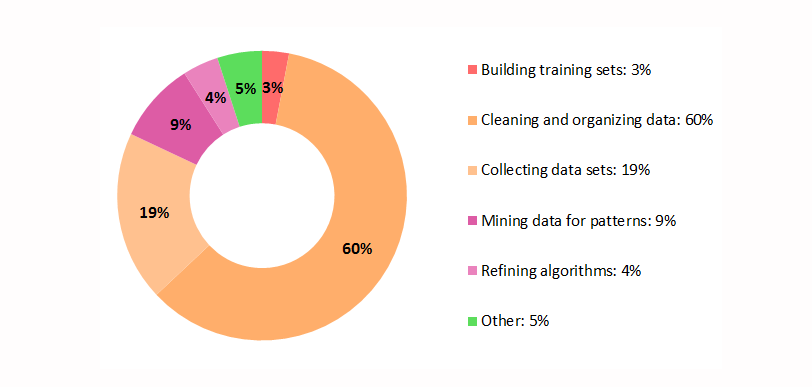

The first step is to separate the independent variables and target(bank_account) from the train data. Then transform the target values from the object data type into numerical by using [LabelEncoder](https://towardsdatascience.com/categorical-encoding-using-label-encoding-and-one-hot-encoder-911ef77fb5bd).


In [10]:
#import preprocessing module
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# Cobvert target label to numerical Data
le = LabelEncoder()
train['bank_account'] = le.fit_transform(train['bank_account'])

#Separate training features from target
X_train = train.drop(['bank_account'], axis=1)
y_train = train['bank_account']

print(y_train)

0        1
1        0
2        1
3        0
4        0
        ..
23519    0
23520    0
23521    0
23522    0
23523    0
Name: bank_account, Length: 23524, dtype: int64


The target values have been transformed into numerical datatypes, **1** represents **‘Yes’** and **0** represents **‘No’**.

We have created a simple preprocessing function to:

*   Handle conversion of data types
*   Convert categorical features to numerical features by using [One-hot Encoder and Label Encoder](https://towardsdatascience.com/categorical-encoding-using-label-encoding-and-one-hot-encoder-911ef77fb5bd)
*   Drop uniqueid variable
*   Perform [feature scaling](https://towardsdatascience.com/preprocessing-with-sklearn-a-complete-and-comprehensive-guide-670cb98fcfb9).

The processing function will be used for both train and test independent variables.

In [11]:
# function to preprocess our data from train models
def preprocessing_data(data):

    # Convert the following numerical labels from interger to float
    float_array = data[["household_size", "age_of_respondent", "year"]].values.astype(float)

    # categorical features to be onverted to One Hot Encoding
    categ = ["relationship_with_head",
             "marital_status",
             "education_level",
             "job_type",
             "country"]

    # One Hot Encoding conversion
    data = pd.get_dummies(data, prefix_sep="_", columns=categ)

    # Label Encoder conversion
    data["location_type"] = le.fit_transform(data["location_type"])
    data["cellphone_access"] = le.fit_transform(data["cellphone_access"])
    data["gender_of_respondent"] = le.fit_transform(data["gender_of_respondent"])

    # drop uniquid column
    data = data.drop(["uniqueid"], axis=1)

    # scale our data into range of 0 and 1
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data)

    return data

Preprocess both train and test dataset.

In [12]:
# preprocess the train data
processed_train = preprocessing_data(X_train)
processed_test = preprocessing_data(test)

Observe the first row in the train data.

In [13]:
# the first train row
print(processed_train[:1])

[[1.        0.        1.        0.1       0.0952381 0.        0.
  0.        0.        0.        0.        1.        0.        0.
  1.        0.        0.        0.        0.        0.        1.
  0.        0.        0.        0.        0.        0.        0.
  0.        0.        0.        0.        1.        1.        0.
  0.        0.       ]]


Observe the shape of the train data.

In [14]:
# shape of the processed train set
print(processed_train.shape)

(23524, 37)


Now we have more independent variables than before (37 variables). This doesn’t mean all these variables are important to train our model. You need to select only important features that can increase the performance of the model. But we will not apply any feature selection technique in this article; if you want to learn and know more about feature selection techniques, we recommend you read the following articles:


*    [Introduction to Feature Selection methods with an example (or how to select the right variables?)](https://https://www.analyticsvidhya.com/blog/2016/12/introduction-to-feature-selection-methods-with-an-example-or-how-to-select-the-right-variables/)
*   [The 5 Feature Selection Algorithms every Data Scientist should know](https://towardsdatascience.com/the-5-feature-selection-algorithms-every-data-scientist-need-to-know-3a6b566efd2)
*   [How to Choose a Feature Selection Method For Machine Learning](https://machinelearningmastery.com/feature-selection-with-real-and-categorical-data/)
*   [Feature Selection Techniques in Machine Learning with Python](https://towardsdatascience.com/feature-selection-techniques-in-machine-learning-with-python-f24e7da3f36e)

###4. Model Building and Experiments
A portion of the train data set will be used to evaluate our models and find the best one that performs well before using it in the test dataset.


In [22]:
import sklearn.model_selection

In [15]:
# Split train_data
from sklearn.model_selection import train_test_split

X_Train, X_Val, y_Train, y_val = train_test_split(processed_train, y_train, stratify = y_train,
                                                  test_size = 0.1, random_state=42)

Only 10% of the train dataset will be used for evaluating the models. The parameter stratify = y_train will ensure an equal balance of values from both classes (‘yes’ and ‘no’) for both train and validation set.

There are many models to choose from such as

*   [K Nearest Neighbors](https://www.datacamp.com/community/tutorials/k-nearest-neighbor-classification-scikit-learn)
*   [Logistic Regression](https://machinelearningmastery.com/logistic-regression-tutorial-for-machine-learning/)
*   [Random Forest](https://www.datacamp.com/community/tutorials/random-forests-classifier-python)

We will be using [**XGBoost**](https://www.datacamp.com/community/tutorials/xgboost-in-python).

We will start by training these models using the train set after splitting our train dataset.

The evaluation metric for this challenge will be the percentage of survey respondents for whom you predict the binary 'bank account' classification incorrectly.

This means the **lower** the incorrect percentage we get, the better the model performance.

In [16]:
from sklearn.metrics import mean_absolute_error
from xgboost import XGBClassifier

model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model.fit(X_Train, y_Train)

# 📈 Step 9: Predict and Evaluate with MAE
y_val_pred = model.predict(X_Val)
mae = mean_absolute_error(y_val, y_val_pred)
print(f"✅ Mean Absolute Error (MAE): {mae:.4f}")

✅ Mean Absolute Error (MAE): 0.1122


Let’s check the confusion matrix for XGB model.

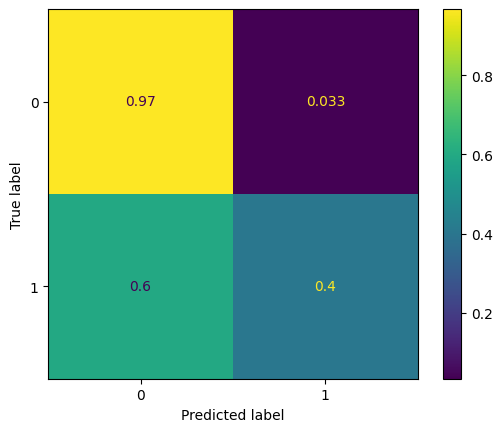

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get confusion matrix for Gradient Boosting Classifier
cm = confusion_matrix(y_val, xg_y_model, normalize='true')
# Assuming xg_y_model are the predictions from your XGBoost model
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Our XGBoost model performs well on predicting **class 0** and performs poorly on predicting **class 1**, it may be caused by the imbalance of data provided(the target variable has more ‘No’ values than ‘Yes’ values). You can learn the best way to deal with imbalanced data here.

One way to increase the model performance is by applying the Grid search method as an approach to parameter tuning that will methodically build and evaluate a model for each combination of algorithm parameters specified in a grid. You can skip this cell if you would like.

In [28]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Optimize model parameters
# I run this code in google colab to make the execution much faster and use the best params in the next code
param_grid = {'min_child_weighth': [1, 5, 10],
        'gamma': [0.5, 1],
        'subsample': [0.6, 0.8, 1.0],
        'max_depth': [3, 5]
        }
my_xgb_model = GridSearchCV(xg_model, param_grid,n_jobs=-1,verbose=2,cv=5)
my_xgb_model.fit(X_Train, y_Train)
print(my_xgb_model.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.6; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.8; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=1.0; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.6; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.8; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.6; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.8; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.8; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.6; total time=   0.1s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subsample=0.6; total time=   0.2s
[CV] END gamma=0.5, max_depth=3, min_child_weighth=1, subs

The above source code will evaluate which parameter values for min_child_weight, gamma, subsample and max_depth will give us better performance.

Let’s use these parameter values and see if the XGB model performance will increase.

In [26]:
# import evaluation metrics
from sklearn.metrics import confusion_matrix, accuracy_score

# evaluate the model
xg_y_model = xg_model.predict(X_Val)

# Get error rate
print("Error rate of XGB classifier: ", 1 - accuracy_score(y_val, xg_y_model))

Error rate of XGB classifier:  0.11219719507012327


In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score

# fit by setting best parameters and Evaluate model
xgb_model = XGBClassifier(min_child_weight=1, gamma=1, subsample=0.8, max_depth=5)

xgb_model.fit(X_Train, y_Train)
y_pred = xgb_model.predict(X_Val)

# Get error rate
print("Error rate of the XGB classifier: ", 1 - accuracy_score(y_val, y_pred))

Error rate of the XGB classifier:  0.10879728006799827


Our XGB model has improved from the previous performance of **0.110** to **0.111**.


###5. Making the first submission
After improving the XGBoost model performance, let’s now see how the model performs on the competition test data set provided and how we rank on the competition leaderboard.

First, we make predictions on the competition test data set.

In [ ]:
# For submission
test_probs = model.predict_proba(processed_test)[:, 1]  # probability of class 1 (bank account = Yes)

# For evaluation
val_probs = model.predict_proba(X_val)[:, 1]
val_preds = (val_probs > 0.5).astype(int)


In [31]:
# Get the predicted result for the test Data
test.bank_account = xgb_model.predict(processed_test)

Improving the Model
1. Switch to MAE Evaluation

✅ Enhancement 2: Threshold Tuning with Probabilities
🎯 Why?
By default, .predict() uses a 0.5 threshold. But in imbalanced datasets, adjusting the threshold based on the class distribution or optimizing MAE on validation can yield better results.

In [ ]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
print("MAE:", mae)

In [1]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Step 1: Predict Probabilities
# predict_proba returns probability of class 0 and class 1
y_val_probs = model.predict_proba(X_Val)[:, 1]  # probability of class 1 (bank_account = 1)

# Step 2: Threshold Search
# Try multiple thresholds to find the one that minimizes MAE
best_threshold = 0.5
best_mae = float("inf")

for t in np.arange(0.2, 0.81, 0.01):
    preds = (y_val_probs >= t).astype(int)
    mae = mean_absolute_error(y_val, preds)
    if mae < best_mae:
        best_mae = mae
        best_threshold = t

print(f"✅ Best threshold: {best_threshold:.2f}")
print(f"🔻 MAE at best threshold: {best_mae:.4f}")


NameError: name 'model' is not defined

3. Feature Selection
🎯 Goal:
Identify the most important features used by your model, so you can:

Eliminate noise (less useful features)

Improve generalization (reduce overfitting)

Make the model faster and easier to interpret





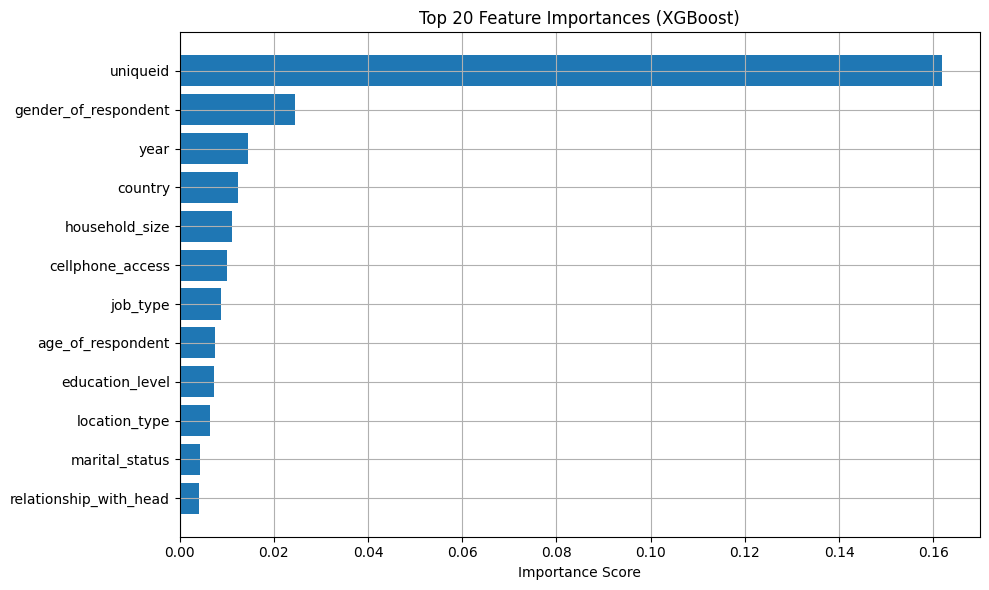

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the trained XGBoost model
importances = model.feature_importances_
feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f"f{i}" for i in range(processed_train.shape[1])]

# Pair and sort
feature_importance = sorted(zip(importances, feature_names), reverse=True)
top_features = feature_importance[:20]  # top 20

# Plot
plt.figure(figsize=(10, 6))
plt.barh([name for _, name in reversed(top_features)],
         [imp for imp, _ in reversed(top_features)])
plt.xlabel("Importance Score")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
# 🧠 Feature Importance Filter
importances = model.feature_importances_
important_indices = [i for i, imp in enumerate(importances) if imp > 0]
processed_train_reduced = processed_train[:, important_indices]

# 🔁 Train-Validation Split (Reduced)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    processed_train_reduced, y_train, test_size=0.1, stratify=y_train, random_state=42
)

# 🤖 Retrain Model
model_reduced = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model_reduced.fit(X_train_split, y_train_split)

# 📈 Evaluate MAE
y_val_probs = model_reduced.predict_proba(X_val_split)[:, 1]
y_val_preds = (y_val_probs >= 0.5).astype(int)
mae_reduced = mean_absolute_error(y_val_split, y_val_preds)

print(f"✅ MAE after dropping low-importance features: {mae_reduced:.4f}")

✅ MAE after dropping low-importance features: 0.1122


Enhancement 4: SHAP Explainability is primarily focused on interpreting your current model (e.g., XGBoost). It helps you answer:

"Which features drive predictions the most?"

"Why did the model predict Yes for person A and No for person B?"

"Are there surprising or unintended feature effects?"



In [27]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Load your training data
df = pd.read_csv("Train.csv")

# Drop target and ID
X_train_raw = df.drop(columns=["bank_account", "uniqueid"])

# 1️⃣ One-hot encode categorical columns
categ_cols = [
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type",
    "country"
]
X_encoded = pd.get_dummies(X_train_raw, prefix_sep="_", columns=categ_cols)

# 2️⃣ Label encode binary categorical columns
le = LabelEncoder()
X_encoded["location_type"] = le.fit_transform(X_encoded["location_type"])
X_encoded["cellphone_access"] = le.fit_transform(X_encoded["cellphone_access"])
X_encoded["gender_of_respondent"] = le.fit_transform(X_encoded["gender_of_respondent"])

# 3️⃣ Scale all features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

# 4️⃣ Capture feature names
all_feature_names = X_encoded.columns.tolist()

# 5️⃣ Filter only the reduced features (from SHAP selection)
# Assuming you already have this from SHAP feature pruning:
# important_indices = [i for i, imp in enumerate(model.feature_importances_) if imp > 0]
reduced_feature_names = [all_feature_names[i] for i in important_indices]


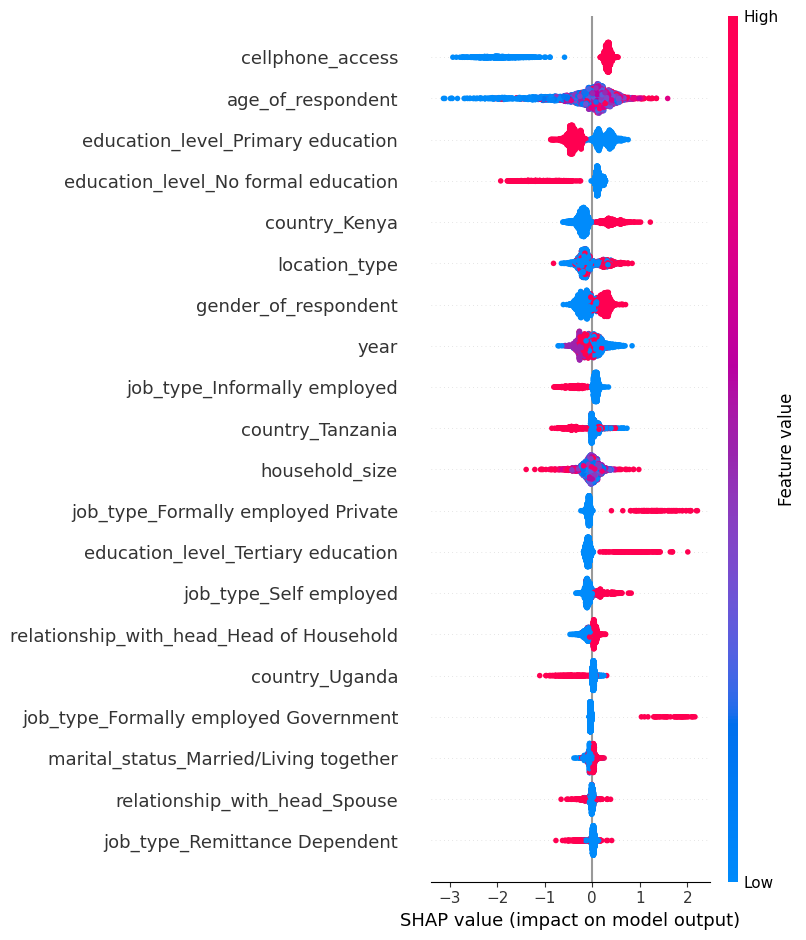

In [28]:
shap.summary_plot(shap_values, features=X_val_split, feature_names=reduced_feature_names)

| Feature                                    | High Value (Red) Effect                 | Low Value (Blue) Effect                 | Business Insight                                                 |
| ------------------------------------------ | --------------------------------------- | --------------------------------------- | ---------------------------------------------------------------- |
| `cellphone_access`                         | Strongly increases bank account chances | Strongly decreases chances              | 🔑 Key access enabler; mobile access ≈ financial access          |
| `age_of_respondent`                        | Mixed impact (middle age = peak?)       | Younger = less likely                   | 👥 Likely working-age group are most included                    |
| `education_level_Primary education`        | Slight positive impact                  | No formal education has strong negative | 🎓 Basic education is a minimum requirement                      |
| `education_level_No formal education`      | Strong negative impact                  |                                         | 🚫 Financial exclusion tied to low literacy                      |
| `country_Kenya`                            | Positive association                    |                                         | 🇰🇪 Kenya is leading in inclusion (e.g. M-Pesa)                 |
| `location_type` (Urban = 1?)               | Higher inclusion                        | Rural = lower inclusion                 | 🏙️ Urban-rural divide remains strong                            |
| `gender_of_respondent` (Female = 1?)       | Gender differences (blue = male?)       |                                         | 👩 Gender may play a role; female-led access strategies?         |
| `job_type_Informally employed`             | Slightly reduces inclusion              |                                         | 👷 Informal employment limits access                             |
| `job_type_Formally employed Private`       | Improves access                         |                                         | 🏢 Formal jobs signal financial identity                         |
| `education_level_Tertiary education`       | Boosts inclusion                        |                                         | 🎓 Advanced education opens up financial channels                |
| `relationship_with_head_Head of Household` | Mixed impact                            |                                         | 🏠 Headship may relate to decision-making, but not always access |
| `job_type_Remittance Dependent`            | Negative impact                         |                                         | 💸 Dependency on remittances signals economic fragility          |


4. Model Comparison
In addition to XGBoost and LightGBM, try:

RandomForestClassifier

CatBoostClassifier

Logistic Regression (as baseline)

Use cross-validation to compare them.

In [29]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

# Dictionary to store MAEs
mae_scores = {}

# Reuse processed_train_reduced and y_train
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    processed_train_reduced, y_train, test_size=0.1, stratify=y_train, random_state=42
)

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_split, y_train_split)
    y_val_probs = model.predict_proba(X_val_split)[:, 1]
    y_val_preds = (y_val_probs >= 0.5).astype(int)
    mae = mean_absolute_error(y_val_split, y_val_preds)
    mae_scores[name] = mae
    print(f"✅ {name} MAE: {mae:.4f}")


✅ Logistic Regression MAE: 0.1126
✅ Random Forest MAE: 0.1356
✅ Gradient Boosting MAE: 0.1088
✅ XGBoost MAE: 0.1122


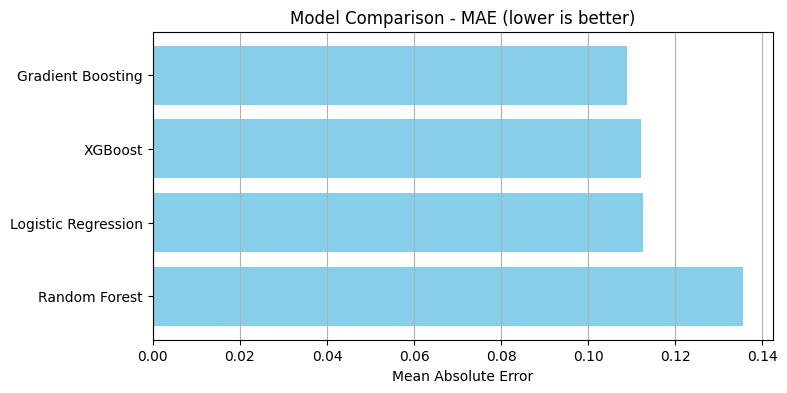

In [30]:
import matplotlib.pyplot as plt

# Sort by MAE
sorted_scores = dict(sorted(mae_scores.items(), key=lambda item: item[1]))

plt.figure(figsize=(8, 4))
plt.barh(list(sorted_scores.keys()), list(sorted_scores.values()), color='skyblue')
plt.xlabel("Mean Absolute Error")
plt.title("Model Comparison - MAE (lower is better)")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()


In [31]:
from sklearn.ensemble import GradientBoostingClassifier

final_model = GradientBoostingClassifier()
final_model.fit(processed_train_reduced, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [34]:
test

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent
...,...,...,...,...,...,...,...,...,...,...,...,...
10081,Uganda,2018,uniqueid_2998,Rural,No,2,62,Female,Spouse,Married/Living together,Primary education,Self employed
10082,Uganda,2018,uniqueid_2999,Urban,Yes,8,42,Male,Head of Household,Married/Living together,Primary education,Self employed
10083,Uganda,2018,uniqueid_3000,Urban,Yes,1,39,Male,Head of Household,Single/Never Married,Secondary education,Other Income
10084,Uganda,2018,uniqueid_3001,Rural,Yes,6,28,Female,Spouse,Married/Living together,Primary education,Self employed


In [38]:
#from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

# Categorical columns
label_cols = ["location_type", "cellphone_access", "gender_of_respondent"]
onehot_cols = ["relationship_with_head", "marital_status", "education_level", "job_type", "country"]

# Store encoders and scaler
encoders = {}
scaler = MinMaxScaler()


In [39]:
def preprocess_train(df):
    df = df.copy()
    df = df.drop(columns=["uniqueid", "bank_account"])
    
    # Label encode
    for col in label_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

    # One-hot encode
    df = pd.get_dummies(df, prefix_sep="_", columns=onehot_cols)

    # Save column order
    col_order = df.columns.tolist()
    
    # Scale
    scaled = scaler.fit_transform(df)
    
    return scaled, col_order


In [40]:
def preprocess_test(df, col_order):
    df = df.copy()
    df = df.drop(columns=["uniqueid"])

    # Label encode using saved encoders
    for col in label_cols:
        df[col] = encoders[col].transform(df[col])
    
    # One-hot encode
    df = pd.get_dummies(df, prefix_sep="_", columns=onehot_cols)

    # Align columns with training
    df = df.reindex(columns=col_order, fill_value=0)

    # Scale using training scaler
    scaled = scaler.transform(df)

    return scaled


In [42]:
# Train
train_df = pd.read_csv("Train.csv")
X_train_scaled, col_order = preprocess_train(train_df)
y_train = train_df["bank_account"]

# Test
test_df = pd.read_csv("Test.csv")
X_test_scaled = preprocess_test(test_df, col_order)


In [45]:
from sklearn.metrics import mean_absolute_error

# Reduce validation set using SHAP-selected features
X_val_reduced = X_Val[:, important_indices]  # important_indices must match training

# Predict probabilities
y_val_probs = final_model.predict_proba(X_val_reduced)[:, 1]

# Convert probabilities to binary predictions using 0.5 threshold
y_val_preds = (y_val_probs >= 0.5).astype(int)

# Compute MAE
mae = mean_absolute_error(y_val, y_val_preds)

print(f"✅ Mean Absolute Error: {mae:.4f}")


✅ Mean Absolute Error: 0.1054


The MAE has improved to 0.1054.

In [47]:
# Important: this must match how you reduced the training set
X_test_reduced = X_test_scaled[:, important_indices]


In [52]:
# Predict probabilities
test_probs = final_model.predict_proba(X_test_reduced)[:, 1]

# Apply threshold (default 0.5)
test_preds = (test_probs >= 0.5).astype(int)


Then we create a submission file according to the instruction provided in the SubmissionFile.csv.


In [53]:
submission = pd.DataFrame({
    "uniqueid": test["uniqueid"] + " x " + test["country"],
    "bank_account": test_preds
})

In [32]:
# Create submission DataFrame
submission = pd.DataFrame({"uniqueid": test["uniqueid"] + " x " + test["country"],
                           "bank_account": test.bank_account})

Let’s observe the sample results from our submission DataFrame.


In [54]:
#show the five sample
submission.sample(5)

,uniqueid,bank_account
3151,uniqueid_9286 x Rwanda,0
9047,uniqueid_9322 x Tanzania,0
3214,uniqueid_9349 x Rwanda,0
9364,uniqueid_2281 x Uganda,0
4881,uniqueid_11016 x Rwanda,0


Save results in the CSV file.


In [51]:
# Create submission csv file csv file
submission.to_csv('first_submission.csv', index = False)
# files.download('first_submission.csv')

We named our submission file a **first_submission.csv**. Now we can upload it to the Zindi competition page by clicking the submit button and selecting the file to upload., You also have an option to add comments for each submission.

###More Tips
- Thorough EDA and domain knowledge sourcing
- Re-group Categorical features
- More Feature Engineering
- Dataset balancing - oversampling, undersampling, SMOTE...
- Ensembling of models
- Cross-validation: Group folds, Stratified...

# ******************* GOOD LUCK!!! ***************************